# LLM Inference Perf Lab (Colab)

Runs vLLM in this Colab runtime, then exercises it with the OpenAI-compatible client from `src/client.py`.

**Requirements**
- Colab runtime with a GPU (Runtime → Change runtime type → GPU)
- Run cells top to bottom (or Runtime → Run all)

**Sections**
1. Environment setup
2. Start vLLM server
3. Client configuration
4. Single request benchmark
5. Streaming benchmark
6. Concurrency sweep

Setup cells are adapted from `notebooks/vllm_setup.ipynb`. The first `vllm serve` run downloads `Qwen/Qwen2.5-1.5B-Instruct` from Hugging Face.


## 1. Environment setup

GPU check, install PyTorch / vLLM / OpenAI client, then verify imports.

### GPU

In [1]:
!nvidia-smi

Fri Jul 17 23:40:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install

In [2]:
!pip install -q uv
!pip install -q \
  "torch==2.9.0" \
  "torchvision==0.24.0" \
  "torchaudio==2.9.0" \
  --index-url https://download.pytorch.org/whl/cu128

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 81.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 40.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 94.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 132.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 900.9/900.9 MB 772.1 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 93.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 6.2 MB/s eta 0:00:00:00:0100:01


In [3]:
!pip install -q "vllm==0.11.2" openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.3/370.3 MB 1.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.0/355.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 7.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━

### Verify

In [4]:
import importlib.metadata as metadata
import torch

print("Installed vLLM package:", metadata.version("vllm"))
print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Installed vLLM package: 0.11.2
PyTorch: 2.9.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
GPU: Tesla T4


In [5]:
import vllm

print("vLLM import successful")
print("vLLM version:", vllm.__version__)

vLLM import successful
vLLM version: 0.11.2


## 2. Start vLLM server

Serves `Qwen/Qwen2.5-1.5B-Instruct` as `qwen2.5-1.5b` on port 8000. Logs go to `/content/vllm_server.log`.

First start can take several minutes while the model downloads and loads. The wait cell tails the log so you can watch progress.

### Launch

In [6]:
%%bash

nohup vllm serve Qwen/Qwen2.5-1.5B-Instruct \
  --host 0.0.0.0 \
  --port 8000 \
  --served-model-name qwen2.5-1.5b \
  --dtype half \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.85 \
  > /content/vllm_server.log 2>&1 &

echo $! > /content/vllm_server.pid
echo "Server process started with PID $(cat /content/vllm_server.pid)"

Server process started with PID 2398


### Wait until ready

In [7]:
import os
import time
from pathlib import Path

import requests

url = "http://127.0.0.1:8000/v1/models"
log_path = Path("/content/vllm_server.log")
pid_path = Path("/content/vllm_server.pid")

pid = int(pid_path.read_text().strip())
log_offset = 0
started = time.monotonic()
poll_s = 2

print(f"Waiting for server (PID {pid}) to become ready...")
print(f"Tailing {log_path}\n")

while True:
    if log_path.exists():
        with log_path.open("r", errors="replace") as log_file:
            log_file.seek(log_offset)
            chunk = log_file.read()
            log_offset = log_file.tell()
        if chunk:
            print(chunk, end="" if chunk.endswith("\n") else "\n", flush=True)

    try:
        response = requests.get(url, timeout=2)
        if response.status_code == 200:
            elapsed_s = time.monotonic() - started
            print(f"\nServer is ready after {elapsed_s:.0f}s.")
            print(response.json())
            break
    except requests.RequestException:
        pass

    try:
        os.kill(pid, 0)
    except OSError as exc:
        print("\nServer process exited before becoming ready.")
        print("\nLast part of server log:\n")
        if log_path.exists():
            print(log_path.read_text(errors="replace")[-5000:])
        raise RuntimeError(f"vLLM server process {pid} is not running") from exc

    time.sleep(poll_s)


Waiting for server (PID 2398) to become ready...
Tailing /content/vllm_server.log

2026-07-17 23:44:22.275254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO 07-17 23:44:35 [scheduler.py:216] Chunked prefill is enabled with max_num_batched_tokens=2048.
(APIServer pid=2398) INFO 07-17 23:44:35 [api_server.py:1977] vLLM API server version 0.11.2
(APIServer pid=2398) INFO 07-17 23:44:35 [utils.py:253] non-default args: {'model_tag': 'Qwen/Qwen2.5-1.5B-Instruct', 'host': '0.0.0.0', 'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'dtype': 'half', 'max_model_len': 2048, 'served_model_name': ['qwen2.5-1.5b'], 'gpu_memory_utilization': 0.85}
(APIServer pid=2398) INFO 07-17 23:44:57 [model.py:631] Resolved architecture: Qwen2ForCausalLM
(APIServer pid=2398) 

## 3. Client configuration

Defaults match `src/client.py` and the local vLLM server started above.

### Settings

In [8]:
# @title Client settings
BASE_URL = "http://127.0.0.1:8000/v1"  # @param {type:"string"}
API_KEY = "not-needed"  # @param {type:"string"}
MODEL_NAME = "qwen2.5-1.5b"  # @param {type:"string"}
MAX_TOKENS = 100  # @param {type:"integer"}
TEMPERATURE = 0.0  # @param {type:"number"}
PROMPT = "What is LLM inference latency?"  # @param {type:"string"}

print(f"base_url={BASE_URL}")
print(f"model={MODEL_NAME}")

base_url=http://127.0.0.1:8000/v1
model=qwen2.5-1.5b


### Create client

In [9]:
from openai import OpenAI

client = OpenAI(
    base_url=BASE_URL,
    api_key=API_KEY,
)

print("Client ready.")

Client ready.


## 4. Single request benchmark

Same call as `src/client.py`, with wall-clock latency.

In [10]:
import time

t0 = time.perf_counter()
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": PROMPT,
        },
    ],
    max_tokens=MAX_TOKENS,
    temperature=TEMPERATURE,
)
elapsed_s = time.perf_counter() - t0

content = response.choices[0].message.content
usage = response.usage

print(content)
print()
print(f"latency_s={elapsed_s:.3f}")
if usage is not None:
    print(f"prompt_tokens={usage.prompt_tokens}")
    print(f"completion_tokens={usage.completion_tokens}")
    print(f"total_tokens={usage.total_tokens}")
    if usage.completion_tokens and elapsed_s > 0:
        # E2E rate (includes prefill/scheduling/HTTP), not pure decode throughput.
        print(
            f"output_tokens_per_e2e_s={usage.completion_tokens / elapsed_s:.2f}"
        )

LLM inference latency refers to the time it takes for an artificial intelligence language model (LLM) to generate a response or output after receiving input data. This can be influenced by various factors such as:

1. Model complexity: More complex models may take longer to process and respond.

2. Data size: Larger datasets require more processing power and time to analyze.

3. Hardware limitations: The computational resources available on the server hosting the model will affect performance.

4. Network conditions: Slow internet connections

latency_s=4.560
prompt_tokens=36
completion_tokens=100
total_tokens=136
output_tokens_per_e2e_s=21.93


## 5. Streaming benchmark

Measures time-to-first-token (TTFT) and end-to-end latency.

In [11]:
import time

t0 = time.perf_counter()
ttft_s = None
chunks: list[str] = []
usage = None

stream = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": PROMPT}],
    max_tokens=MAX_TOKENS,
    temperature=TEMPERATURE,
    stream=True,
    stream_options={"include_usage": True},
)

for event in stream:
    if getattr(event, "usage", None) is not None:
        usage = event.usage
    if not event.choices:
        continue
    delta = event.choices[0].delta.content
    if not delta:
        continue
    if ttft_s is None:
        ttft_s = time.perf_counter() - t0
    chunks.append(delta)
    print(delta, end="", flush=True)

elapsed_s = time.perf_counter() - t0
print()
print()
print(f"ttft_s={ttft_s:.3f}" if ttft_s is not None else "ttft_s=n/a")
print(f"e2e_latency_s={elapsed_s:.3f}")
print(f"output_chars={sum(len(c) for c in chunks)}")
if usage is not None:
    print(f"prompt_tokens={usage.prompt_tokens}")
    print(f"completion_tokens={usage.completion_tokens}")
    print(f"total_tokens={usage.total_tokens}")
    if usage.completion_tokens and elapsed_s > 0:
        print(
            f"output_tokens_per_e2e_s={usage.completion_tokens / elapsed_s:.2f}"
        )
else:
    print("usage=n/a (stream did not include usage)")


LLM inference latency refers to the time it takes for an artificial intelligence language model (LLM) to generate a response or output after receiving input data. This can be influenced by various factors such as:

1. Model complexity: More complex models may take longer to process and respond.

2. Data size: Larger datasets require more processing power and time to analyze.

3. Hardware limitations: The computational resources available on the server hosting the model will affect performance.

4. Network conditions: Slow internet connections

ttft_s=0.073
e2e_latency_s=1.701
output_chars=548
prompt_tokens=36
completion_tokens=100
total_tokens=136
output_tokens_per_e2e_s=58.81


## 6. Concurrency sweep

Fires the same prompt at several concurrency levels (thread pool). For each level, records per-request latency/`usage` and batch wall-clock throughput.

Writes `results/concurrency_raw.csv` and `results/concurrency_summary.csv`.

In [25]:
def run_one_request(request_id):
    t0 = time.perf_counter()
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": PROMPT}],
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )

    elapsed_s = time.perf_counter() - t0

    usage = response.usage

    prompt_tokens = usage.prompt_tokens if usage is not None else None
    completion_tokens = usage.completion_tokens if usage is not None else None
    total_tokens = usage.total_tokens if usage is not None else None

    output_tokens_per_e2e_s = None
    if completion_tokens is not None and elapsed_s > 0:
        output_tokens_per_e2e_s = completion_tokens / elapsed_s

    return {
        "request_id": request_id,
        "latency_s": elapsed_s,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens,
        "output_tokens_per_e2e_s": output_tokens_per_e2e_s,
    }

In [13]:
result = run_one_request(request_id=0)
print(result)

{'request_id': 0, 'latency_s': 1.6832898370000748, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 59.40747564793594}


In [26]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def run_concurrency_level(concurrency, repeat_id):
    experiment_start = time.perf_counter()

    results = []

    with ThreadPoolExecutor(max_workers=concurrency) as executor:
        futures = [
            executor.submit(run_one_request, request_id)
            for request_id in range(concurrency)
        ]

        for future in as_completed(futures):
            results.append(future.result())

    experiment_elapsed_s = time.perf_counter() - experiment_start

    total_output_tokens = sum(
        result["completion_tokens"] or 0
        for result in results
    )

    aggregate_output_tokens_per_s = None
    if experiment_elapsed_s > 0:
        aggregate_output_tokens_per_s = total_output_tokens / experiment_elapsed_s

    for result in results:
        result["repeat_id"] = repeat_id
        result["concurrency"] = concurrency
        result["experiment_elapsed_s"] = experiment_elapsed_s
        result["aggregate_output_tokens_per_s"] = (
            aggregate_output_tokens_per_s
        )

    return results


In [ ]:
results = run_concurrency_level(concurrency=2, repeat_id=0)

experiment_elapsed_s = results[0]["experiment_elapsed_s"]
print(f"Experiment elapsed time: {experiment_elapsed_s:.3f}s")
for result in sorted(results, key=lambda r: r["latency_s"]):
    print(result)


Experiment elapsed time: 1.738s
{'request_id': 1, 'latency_s': 1.72030695799981, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 58.12916092385592}
{'request_id': 0, 'latency_s': 1.7370068419998006, 'prompt_tokens': 36, 'completion_tokens': 100, 'total_tokens': 136, 'output_tokens_per_e2e_s': 57.570297123798824}


In [27]:
import os
import pandas as pd

concurrency_levels = [1, 2, 4, 8]
num_repeats = 3

all_results = []

for concurrency in concurrency_levels:
    for repeat_id in range(num_repeats):
        print(
            f"Running concurrency={concurrency}, "
            f"repeat={repeat_id}..."
        )

        results = run_concurrency_level(
            concurrency=concurrency,
            repeat_id=repeat_id,
        )

        all_results.extend(results)

        experiment_elapsed_s = results[0]["experiment_elapsed_s"]
        aggregate_throughput = results[0][
            "aggregate_output_tokens_per_s"
        ]

        print(
            f"  elapsed={experiment_elapsed_s:.3f}s, "
            f"aggregate_output_tokens_per_s="
            f"{aggregate_throughput:.2f}"
        )

        # Brief pause so consecutive experiments are clearly separated.
        time.sleep(1)

Running concurrency=1, repeat=0...
  elapsed=1.688s, aggregate_output_tokens_per_s=59.23
Running concurrency=1, repeat=1...
  elapsed=1.632s, aggregate_output_tokens_per_s=61.28
Running concurrency=1, repeat=2...
  elapsed=1.629s, aggregate_output_tokens_per_s=61.37
Running concurrency=2, repeat=0...
  elapsed=1.699s, aggregate_output_tokens_per_s=117.75
Running concurrency=2, repeat=1...
  elapsed=1.668s, aggregate_output_tokens_per_s=119.92
Running concurrency=2, repeat=2...
  elapsed=1.671s, aggregate_output_tokens_per_s=119.72
Running concurrency=4, repeat=0...
  elapsed=1.713s, aggregate_output_tokens_per_s=233.52
Running concurrency=4, repeat=1...
  elapsed=1.703s, aggregate_output_tokens_per_s=234.92
Running concurrency=4, repeat=2...
  elapsed=1.753s, aggregate_output_tokens_per_s=228.19
Running concurrency=8, repeat=0...
  elapsed=1.775s, aggregate_output_tokens_per_s=450.62
Running concurrency=8, repeat=1...
  elapsed=1.777s, aggregate_output_tokens_per_s=450.30
Running concu

In [28]:
df = pd.DataFrame(all_results)

column_order = [
    "repeat_id",
    "concurrency",
    "request_id",
    "latency_s",
    "prompt_tokens",
    "completion_tokens",
    "total_tokens",
    "output_tokens_per_e2e_s",
    "experiment_elapsed_s",
    "aggregate_output_tokens_per_s",
]

df = (
    df[column_order]
    .sort_values(["concurrency", "repeat_id", "request_id"])
    .reset_index(drop=True)
)

display(df)

,repeat_id,concurrency,request_id,latency_s,prompt_tokens,completion_tokens,total_tokens,output_tokens_per_e2e_s,experiment_elapsed_s,aggregate_output_tokens_per_s
0,0,1,0,1.687899,36,100,136,59.245252,1.688329,59.230176
1,1,1,0,1.631264,36,100,136,61.302147,1.631796,61.282157
2,2,1,0,1.629032,36,100,136,61.386141,1.629485,61.369088
3,0,2,0,1.682683,36,100,136,59.428886,1.698558,117.746943
4,0,2,1,1.696068,36,100,136,58.959894,1.698558,117.746943
6,1,2,0,1.666987,36,100,136,59.988478,1.667781,119.919791
5,1,2,1,1.649368,36,100,136,60.629283,1.667781,119.919791
7,2,2,0,1.653519,36,100,136,60.477094,1.670628,119.715446
8,2,2,1,1.668274,36,100,136,59.942180,1.670628,119.715446
9,0,4,0,1.694387,36,100,136,59.018378,1.712890,233.523461


In [29]:
os.makedirs("results", exist_ok=True)

output_path = "results/concurrency_raw.csv"
df.to_csv(output_path, index=False)

print(f"Saved {len(df)} rows to {output_path}")

Saved 45 rows to results/concurrency_raw.csv


In [ ]:
# Backup CSV before the Colab runtime disconnects.
try:
    from google.colab import files

    files.download("results/concurrency_raw.csv")
except ImportError:
    print("Not running in Colab; skip files.download(). CSV is at results/concurrency_raw.csv")

## Concurrency Analysis


In [34]:
experiment_df = (
    df[
        [
            "concurrency",
            "repeat_id",
            "experiment_elapsed_s",
            "aggregate_output_tokens_per_s",
        ]
    ]
    .drop_duplicates(
        subset=["concurrency", "repeat_id"]
    )
    .sort_values(["concurrency", "repeat_id"])
    .reset_index(drop=True)
)

display(experiment_df)


,concurrency,repeat_id,experiment_elapsed_s,aggregate_output_tokens_per_s
0,1,0,1.688329,59.230176
1,1,1,1.631796,61.282157
2,1,2,1.629485,61.369088
3,2,0,1.698558,117.746943
4,2,1,1.667781,119.919791
5,2,2,1.670628,119.715446
6,4,0,1.712890,233.523461
7,4,1,1.702674,234.924661
8,4,2,1.752955,228.186150
9,8,0,1.775323,450.622122


In [35]:
run_summary = (
    df.groupby(["concurrency", "repeat_id"], as_index=False)
    .agg(
        mean_request_latency_s=("latency_s", "mean"),
        min_request_latency_s=("latency_s", "min"),
        max_request_latency_s=("latency_s", "max"),
        experiment_elapsed_s=("experiment_elapsed_s", "first"),
        aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "first",
        ),
    )
)

display(run_summary)

,concurrency,repeat_id,mean_request_latency_s,min_request_latency_s,max_request_latency_s,experiment_elapsed_s,aggregate_output_tokens_per_s
0,1,0,1.687899,1.687899,1.687899,1.688329,59.230176
1,1,1,1.631264,1.631264,1.631264,1.631796,61.282157
2,1,2,1.629032,1.629032,1.629032,1.629485,61.369088
3,2,0,1.689376,1.682683,1.696068,1.698558,117.746943
4,2,1,1.658177,1.649368,1.666987,1.667781,119.919791
5,2,2,1.660896,1.653519,1.668274,1.670628,119.715446
6,4,0,1.704428,1.694387,1.708891,1.712890,233.523461
7,4,1,1.688845,1.681138,1.696546,1.702674,234.924661
8,4,2,1.738634,1.735675,1.744153,1.752955,228.186150
9,8,0,1.763709,1.750716,1.772095,1.775323,450.622122


In [36]:
summary_df = (
    run_summary.groupby("concurrency", as_index=False)
    .agg(
        mean_latency_s=("mean_request_latency_s", "mean"),
        std_latency_s=("mean_request_latency_s", "std"),
        mean_experiment_elapsed_s=("experiment_elapsed_s", "mean"),
        mean_aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "mean",
        ),
        std_aggregate_output_tokens_per_s=(
            "aggregate_output_tokens_per_s",
            "std",
        ),
    )
)

baseline_throughput = summary_df.loc[
    summary_df["concurrency"] == 1,
    "mean_aggregate_output_tokens_per_s",
].iloc[0]

summary_df["throughput_scaling"] = (
    summary_df["mean_aggregate_output_tokens_per_s"]
    / baseline_throughput
)

summary_df["scaling_efficiency"] = (
    summary_df["throughput_scaling"]
    / summary_df["concurrency"]
)

display(summary_df)

,concurrency,mean_latency_s,std_latency_s,mean_experiment_elapsed_s,mean_aggregate_output_tokens_per_s,std_aggregate_output_tokens_per_s,throughput_scaling,scaling_efficiency
0,1,1.649398,0.033361,1.649870,60.627141,1.210587,1.000000,1.000000
1,2,1.669483,0.017281,1.678989,119.127393,1.199863,1.964919,0.982459
2,4,1.710636,0.025468,1.722839,232.211424,3.555695,3.830156,0.957539
3,8,1.766618,0.003515,1.778511,449.816437,1.126809,7.419391,0.927424


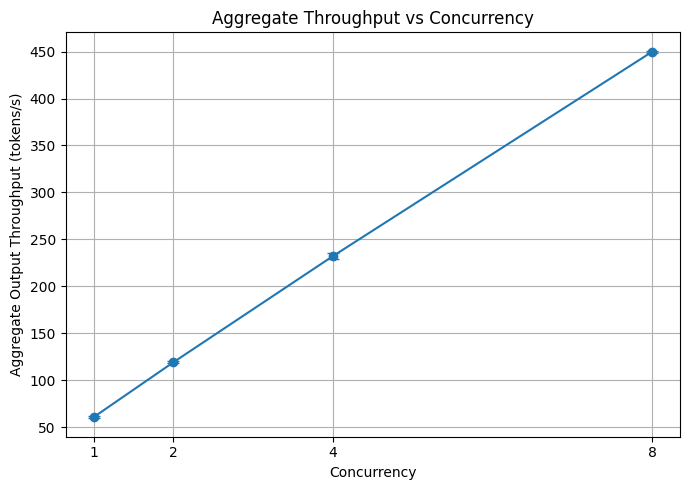

In [37]:
import os
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["concurrency"],
    summary_df["mean_aggregate_output_tokens_per_s"],
    yerr=summary_df["std_aggregate_output_tokens_per_s"],
    marker="o",
    capsize=4,
)

plt.xlabel("Concurrency")
plt.ylabel("Aggregate Output Throughput (tokens/s)")
plt.title("Aggregate Throughput vs Concurrency")
plt.xticks(summary_df["concurrency"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "plots/throughput_vs_concurrency.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

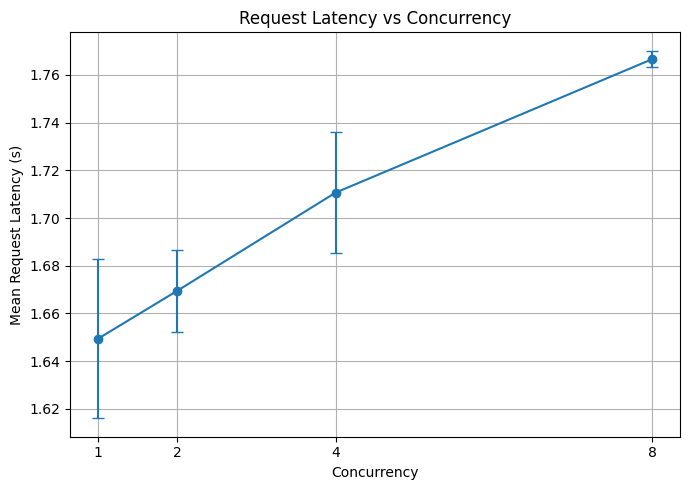

In [38]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    summary_df["concurrency"],
    summary_df["mean_latency_s"],
    yerr=summary_df["std_latency_s"],
    marker="o",
    capsize=4,
)

plt.xlabel("Concurrency")
plt.ylabel("Mean Request Latency (s)")
plt.title("Request Latency vs Concurrency")
plt.xticks(summary_df["concurrency"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "plots/latency_vs_concurrency.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [39]:
summary_df.to_csv(
    "results/concurrency_summary.csv",
    index=False,
)

print("Saved:")
print("- results/concurrency_raw.csv")
print("- results/concurrency_summary.csv")
print("- plots/latency_vs_concurrency.png")
print("- plots/throughput_vs_concurrency.png")

Saved:
- results/concurrency_raw.csv
- results/concurrency_summary.csv
- plots/latency_vs_concurrency.png
- plots/throughput_vs_concurrency.png


In [40]:
import shutil
from google.colab import files

shutil.make_archive(
    "concurrency_experiment",
    "zip",
    root_dir=".",
    base_dir="results",
)

files.download("concurrency_experiment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import os
import shutil
from google.colab import files

os.makedirs("concurrency_experiment/results", exist_ok=True)
os.makedirs("concurrency_experiment/plots", exist_ok=True)

shutil.copy(
    "results/concurrency_raw.csv",
    "concurrency_experiment/results/concurrency_raw.csv",
)
shutil.copy(
    "results/concurrency_summary.csv",
    "concurrency_experiment/results/concurrency_summary.csv",
)
shutil.copy(
    "plots/latency_vs_concurrency.png",
    "concurrency_experiment/plots/latency_vs_concurrency.png",
)
shutil.copy(
    "plots/throughput_vs_concurrency.png",
    "concurrency_experiment/plots/throughput_vs_concurrency.png",
)

shutil.make_archive(
    "concurrency_experiment",
    "zip",
    root_dir=".",
    base_dir="concurrency_experiment",
)

files.download("concurrency_experiment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Concurrency Sweep Observations

The concurrency sweep tested concurrency levels of 1, 2, 4, and 8, with
three repeated runs per level. Each request used the same 36-token prompt
and generated 100 output tokens.

Mean request latency increased from 1.649 seconds at concurrency 1 to
1.767 seconds at concurrency 8, an increase of approximately 7.1%.

Aggregate output throughput increased from 60.63 tokens/s to
449.82 tokens/s, representing a 7.42x throughput improvement at 8x
concurrency.

Scaling efficiency remained high, decreasing from 100% at concurrency 1
to approximately 92.7% at concurrency 8.

These results suggest that, for this workload, vLLM effectively batches
concurrent requests and increases total server throughput with only a
modest latency penalty.

This conclusion is limited to the tested environment and workload:
Tesla T4, Qwen2.5-1.5B-Instruct, a short 36-token prompt, 100 generated
tokens, and concurrency levels up to 8.

## Notes

| Piece | Source |
|---|---|
| GPU check, PyTorch/vLLM install, serve, readiness wait | `notebooks/vllm_setup.ipynb` |
| OpenAI client + latency helpers | `src/client.py` |
| Model | `Qwen/Qwen2.5-1.5B-Instruct` served as `qwen2.5-1.5b` |
| Endpoint | `http://127.0.0.1:8000/v1` (same Colab runtime) |
| Concurrency CSVs | `results/concurrency_raw.csv`, `results/concurrency_summary.csv` |
| Archived runs | `results/run_YYYY-MM-DD/` (`latency_raw.csv`, `summary.md`) |

Server log: `/content/vllm_server.log`  
Server PID: `/content/vllm_server.pid`
